HIV...
SAbDab...
CoV-AbDab...
Yeast...
Human...
Done → homology_plot.png


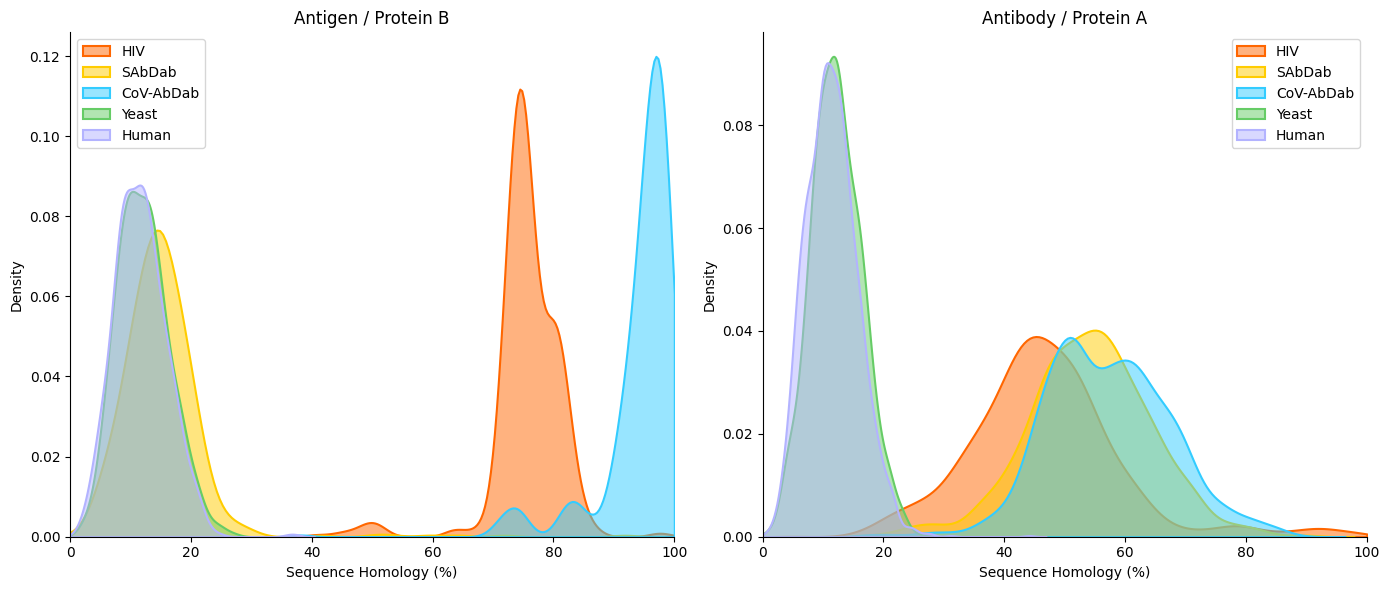

In [5]:
# homology_plot_complete.py
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from openpyxl import load_workbook
from difflib import SequenceMatcher
import random, time

SEED = 42
N_AB = 2000   # samples for short antibody seqs (~1-2ms each)
N_AG = 500    # samples for long antigen seqs (~20ms each)
DATA = '/content'   # adjust to your data directory

def sm_identity(s1, s2):
    return SequenceMatcher(None, s1, s2, autojunk=False).ratio() * 100

def sample_ids(seqs, n=1000, seed=SEED):
    rng = random.Random(seed)
    seqs = [s for s in seqs if s and isinstance(s, str)]
    if len(seqs) < 2: return np.array([])
    idx = list(range(len(seqs)))
    out = []
    for _ in range(n):
        i = rng.choice(idx); j = rng.choice(idx)
        while j == i: j = rng.choice(idx)
        out.append(sm_identity(seqs[i], seqs[j]))
    return np.array(out)

# Load
sabdab = pd.read_csv(f'{DATA}/dataset_sabdab.csv')
wb_hiv = load_workbook(f'{DATA}/dataset_hiv.xlsx', read_only=True)
wb_cov = load_workbook(f'{DATA}/dataset_sars-cov-19.xlsx', read_only=True)
human  = pd.read_csv(f'{DATA}/dataset_human.csv')
yeast  = pd.read_csv(f'{DATA}/dataset_yeast.txt', sep='\t')

def xl_col(wb, col):
    ws = wb.active
    return list({str(r[col]) for i,r in enumerate(ws.iter_rows(values_only=True)) if i and r[col]})

datasets = {
    'SAbDab':    {'ab': sabdab['ab_seq'].dropna().unique().tolist(),
                  'ag': sabdab['ag_seq'].dropna().unique().tolist()},
    'HIV':       {'ab': xl_col(wb_hiv,0), 'ag': xl_col(wb_hiv,1)},
    'CoV-AbDab': {'ab': xl_col(wb_cov,0), 'ag': xl_col(wb_cov,1)},
    'Human':     {'ab': human['Protein_1_Seq'].dropna().unique().tolist(),
                  'ag': human['Protein_2_Seq'].dropna().unique().tolist()},
    'Yeast':     {'ab': yeast['Protein_A_sequence'].dropna().unique().tolist(),
                  'ag': yeast['Protein_B_sequence'].dropna().unique().tolist()},
}

display_order = ['HIV', 'SAbDab', 'CoV-AbDab', 'Yeast', 'Human']

results = {}
for name in display_order:
    d = datasets[name]
    print(f'{name}...', flush=True)
    results[name] = {'ab': sample_ids(d['ab'], N_AB), 'ag': sample_ids(d['ag'], N_AG)}

palette = {'SAbDab':'#ffcc00','HIV':'#ff6600','CoV-AbDab':'#33ccff','Human':'#b3b3ff','Yeast':'#66cc66'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, key, title in zip(axes, ['ag','ab'], ['Antigen / Protein B','Antibody / Protein A']):
    for name in display_order:
        res = results[name]
        d = res[key]
        if len(d) > 5:
            sns.kdeplot(data=d, ax=ax, label=name, color=palette[name],
                        fill=True, alpha=0.5, linewidth=1.5, clip=(0,100))
    ax.set(title=title, xlabel='Sequence Homology (%)', ylabel='Density', xlim=(0,100))
    ax.spines[['top','right']].set_visible(False); ax.legend()
plt.tight_layout()
plt.savefig('homology_plot.png', dpi=150, bbox_inches='tight')
print('Done → homology_plot.png')